In [118]:
%load_ext autoreload
import numpy as np
from utils.data_loader import *
from models import *
import torch.optim as optim
import torch
import torch.nn as nn
import l4casadi
import plotly.graph_objects as go


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


shred.json:  p_heat, engr_heat, engr_cool, pyro

shred2.json: p_heat, p_cool, pyro

shred3.json: p_heat, pyro 

forecaster4: p_hear, pyro

In [55]:
%autoreload 2
parent = ''
filter = pd.concat([pd.read_csv(parent+'data/nodes/c1.csv'),pd.read_csv(parent+'data/nodes/c2.csv'),pd.read_csv(parent+'data/nodes/sus.csv'),pd.read_csv(parent+'data/nodes/outer_wall.csv')])
data_dict,mu_dict,nodes,_ = load_raw_data(parent+'data/raw_data/', filter3D=filter, mu_keys=['Power 3D (kW)', 'Cooling Power 3D (kW)','Pyro 3D (°C)'])      

Index(['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Pyro 3D (°C)'], dtype='str')


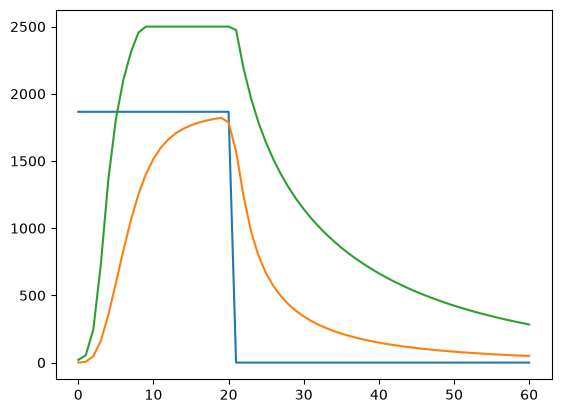

In [56]:
temps = data_dict['PW1']['temps']
mu = mu_dict['PW1']['mu']
print(mu_dict['PW1']['columns'])
for j in range(mu.shape[1]):
    plt.plot(mu[:,j])
plt.show()

In [57]:
%autoreload 2
POD_dim = 10
manager = DatasetManager(
    data_dict=data_dict, 
    mu_dict=mu_dict, 
    train_share=0.8, 
    valid_share=0.1, 
    POD_dim=POD_dim, 
    seq_len=10,
    padding_key = ['zero', 'zero','init']
    )
train_dataset, valid_dataset, test_dataset = manager.make_SHRED_datasets(ykey='POD_coefs')

/home/abhyu/Documents/SINTEF/Gitlab/clean_start/utils/utilities.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.stdev = torch.tensor(np.sqrt(self.var), dtype =torch.float32)


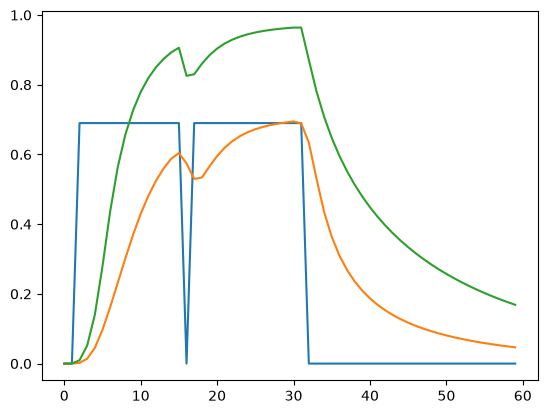

In [80]:
plt.plot(train_dataset.X[:60,-1])

In [58]:
loss_weight = (manager.YscalerPost.max - manager.YscalerPost.min)**2

In [117]:
loss_weight

tensor([4.7024e+04, 1.0158e+04, 1.0480e+03, 1.7603e+02, 2.1891e+02, 4.7115e+01,
        2.9537e+01, 1.2910e+01, 1.4599e+01, 5.1046e+00])

In [116]:
manager.Sr

array([2399.06121565, 1151.8280222 ,  194.71110771,  120.88504123,
         90.04326859,   37.97199634,   30.68958786,   20.59016801,
         17.68946753,   11.40179857])

In [59]:
in_dim = train_dataset.X.shape[-1]
out_dim = train_dataset.Y.shape[-1]
in_dim, out_dim

(3, 10)

Visualizing POD error

In [109]:
def recon_error_plot(Ytrain_unified, POD_modes, to = None, by = 10):
    recon_error_list = []
    U_full,S,Vh_full = scipy.linalg.svd(Ytrain_unified, full_matrices=False)
    # rel_cumsumS = [sum(S[:i])/sum(S) for i in range(len(S))]
    to = len(S) if to is None else to
    print(to)
    n_modes = []
    for l in range(1, to, by):
        n_modes.append(l)
        Vh = Vh_full[:l,:]
        Ytrain_recon = Ytrain_unified @ Vh.T @ Vh
        recon_error_list.append(((Ytrain_unified - Ytrain_recon)**2).mean())
        del Ytrain_recon, Vh
    # Ytrain_recon = Ytrain_unified @ Vh_full.T @ Vh_full
    # recon_error_list.append(((Ytrain_recon - Ytrain_unified)**2).mean())
    # n_modes.append(len(S))


    return n_modes, recon_error_list, Vh_full


/tmp/ipykernel_114956/160238634.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Ytrain_recon = Ytrain_unified @ Vh.T @ Vh
/tmp/ipykernel_114956/160238634.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Ytrain_recon = Ytrain_unified @ Vh_full.T @ Vh_full
/tmp/ipykernel_114956/3438195464.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


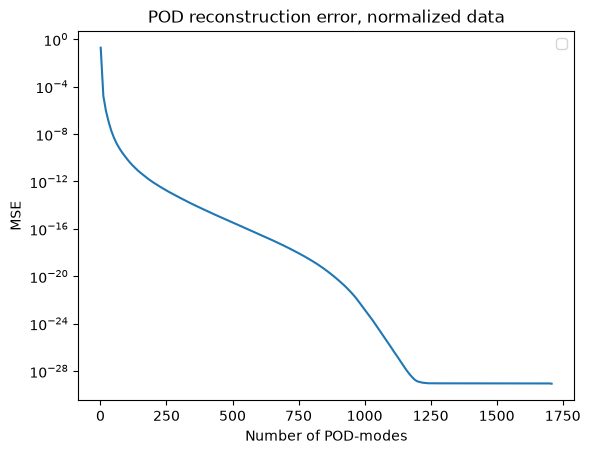

KeyboardInterrupt: 

In [ ]:

POD_modes = 10
Ysamples_unif = manager.YscalerPre.transform(torch.tensor(manager.trainY_unif))

n_modes, recon_error_list,Vh_full  = recon_error_plot(Ysamples_unif, POD_modes)

plt.figure()
plt.semilogy(n_modes, recon_error_list)#, marker='x', ls='dashed')
plt.title('POD reconstruction error, normalized data')
plt.ylabel('MSE')
plt.xlabel('Number of POD-modes')
plt.legend()
plt.show()


50


/tmp/ipykernel_114956/3659237407.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Ytrain_recon = Ytrain_unified @ Vh.T @ Vh


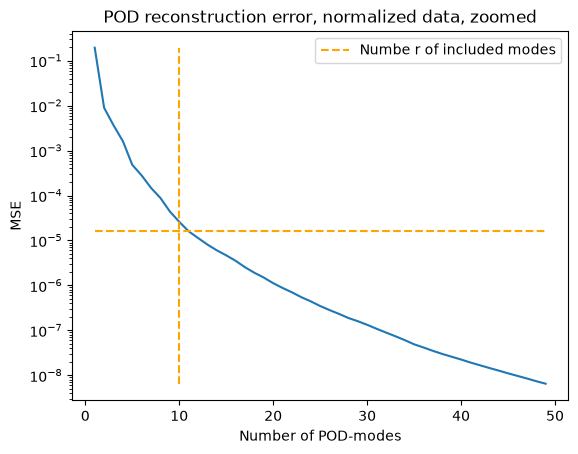

In [ ]:

n_modes, recon_error_list,Vh_full  = recon_error_plot(Ysamples_unif, POD_modes, to=50, by=1)


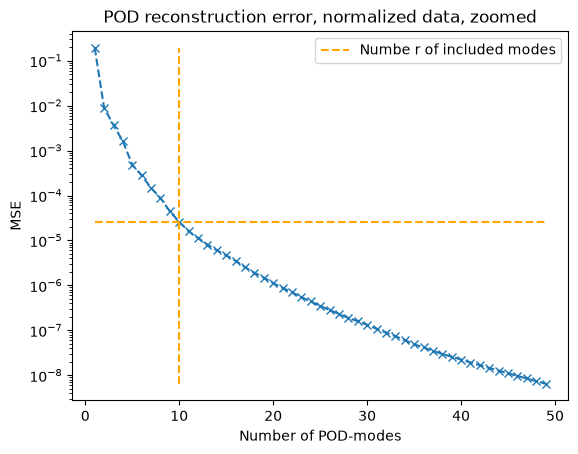

In [113]:

plt.figure()
plt.semilogy(n_modes, recon_error_list, marker='x', ls='dashed')
plt.title('POD reconstruction error, normalized data, zoomed')
plt.ylabel('MSE')
plt.xlabel('Number of POD-modes')
plt.vlines(POD_modes,min(recon_error_list), max(recon_error_list), colors=['orange'], linestyles=['dashed'], label='Numbe r of included modes')
plt.hlines(recon_error_list[POD_modes-1],min(n_modes), max(n_modes), colors=['orange'], linestyles=['dashed'])
plt.legend()
plt.show()



50


/tmp/ipykernel_114956/3659237407.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Ytrain_recon = Ytrain_unified @ Vh.T @ Vh
/tmp/ipykernel_114956/3678558967.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


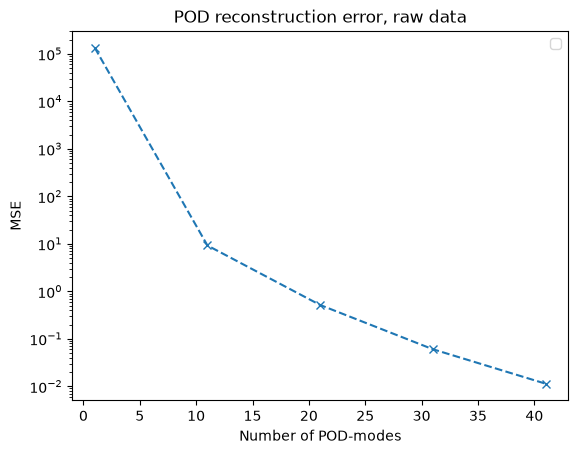

In [114]:
n_modes, recon_error_list,Vh_full  = recon_error_plot(torch.tensor(manager.trainY_unif), POD_modes, to=50,by=10)

plt.figure()
plt.semilogy(n_modes, recon_error_list, marker='x', ls='dashed')
plt.title('POD reconstruction error, raw data')
plt.ylabel('MSE')
plt.xlabel('Number of POD-modes')
# plt.vlines(POD_modes,min(recon_error_list), max(recon_error_list), colors=['orange'], linestyles=['dashed'], label='Numbe r of included modes')
# plt.hlines(recon_error_list[POD_modes],min(n_modes), max(n_modes), colors=['orange'], linestyles=['dashed'])
plt.legend()
plt.show()



In [61]:
c1_picker = torch.tensor(np.loadtxt('data/core_regions/c1_picker.txt'), dtype=torch.float32)
c2_picker = torch.tensor(np.loadtxt('data/core_regions/c2_picker.txt'), dtype=torch.float32)
sus_picker = torch.tensor(np.loadtxt('data/core_regions/sus_picker.txt'), dtype=torch.float32)
outer_wall_picker = torch.tensor(np.loadtxt('data/core_regions/outer_wall_picker.csv'), dtype=torch.float32)
pyro_picker = torch.tensor(np.loadtxt('data/core_regions/pyro_picker.csv'), dtype=torch.float32)

Model definiton

In [62]:
%autoreload 2
shred = SHRED(
   in_dim=train_dataset.X.shape[-1],
   out_dim=train_dataset.Y.shape[-1],
   batch_first=True,
   data_manager=manager,
   lstm_params= {
                  'seq_len': 10, 
                  'n_layers': 2,
                  'hidden_dim': 64,
               },
   sdn_params = {
                  'inner_layers': [200,100],
                  'dropout': [True, 0.1],
                  'batch_norm': [False],
               },
            )


Training

-----Epoch 0-----
Training loss  : 1.0829029220801134
Validation loss: 0.2992558777332306
-----Epoch 1-----
Training loss  : 0.27367107340922725
Validation loss: 0.2087334841489792
-----Epoch 2-----
Training loss  : 0.19779878854751587
Validation loss: 0.1420021802186966
-----Epoch 3-----
Training loss  : 0.1269988502160861
Validation loss: 0.041918933391571045
-----Epoch 4-----
Training loss  : 0.06129805872646662
Validation loss: 0.022578634321689606
-----Epoch 5-----
Training loss  : 0.04609834768164616
Validation loss: 0.015281093306839466
-----Epoch 6-----
Training loss  : 0.03806366857427817
Validation loss: 0.013224001973867416
-----Epoch 7-----
Training loss  : 0.0333921557578903
Validation loss: 0.009803474880754948
-----Epoch 8-----
Training loss  : 0.03182287234812975
Validation loss: 0.008643579669296741
-----Epoch 9-----
Training loss  : 0.028342377466077987
Validation loss: 0.012638689950108528
-----Epoch 10-----
Training loss  : 0.03148669498757674
Validation loss: 0.009

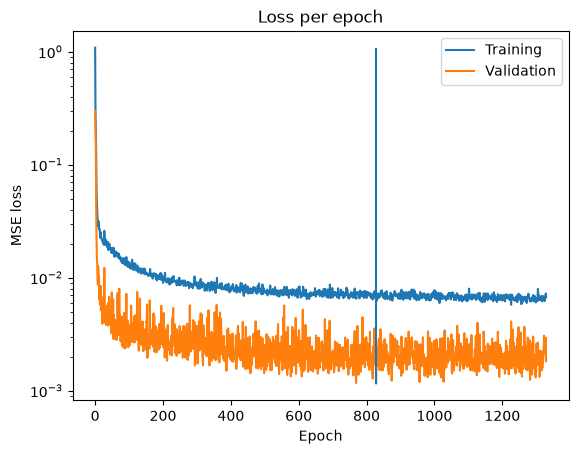

SHRED(
  (lstm): LSTM(
    (lstm): LSTM(3, 64, num_layers=2, batch_first=True)
  )
  (sdn): SDN(
    (layers): ModuleList(
      (0): Linear(in_features=64, out_features=200, bias=True)
      (1): ReLU(inplace=True)
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=200, out_features=100, bias=True)
      (4): ReLU(inplace=True)
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=100, out_features=10, bias=True)
    )
  )
)

In [63]:
%autoreload 2
learning_rate = 1e-3
weight_decay  = 0.1
optimizer = optim.AdamW(shred.parameters(), lr=learning_rate, weight_decay=weight_decay)
# loss = nn.MSELoss(reduction='sum')
loss = WeightedLoss(loss_weight)
train_error, valid_error = shred.fit(
   train_dataset, 
   valid_dataset, 
   optimizer, 
   loss, 
   batch_size = 64, 
   max_epoch = 10000, 
   patience = 500, 
   plotting = True
   )
shred.eval()


Save / Load

In [64]:
torch.save(shred.state_dict(), 'shred_2.json')

In [65]:
weights = torch.load('shred_2.json', weights_only=True)
shred.load_state_dict(weights)
shred.eval()

SHRED(
  (lstm): LSTM(
    (lstm): LSTM(3, 64, num_layers=2, batch_first=True)
  )
  (sdn): SDN(
    (layers): ModuleList(
      (0): Linear(in_features=64, out_features=200, bias=True)
      (1): ReLU(inplace=True)
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=200, out_features=100, bias=True)
      (4): ReLU(inplace=True)
      (5): Dropout(p=0.1, inplace=False)
      (6): Linear(in_features=100, out_features=10, bias=True)
    )
  )
)

Testing

In [66]:
sets = {'Training':train_dataset,'Validation':valid_dataset,'Testing':test_dataset}
for name in sets:
    set = sets[name]
    print(f'-----{name}-----')
    a_pred = shred(set.X)
    a_true = set.Y
    Z_POD_pred = a_pred @ manager.Vtr
    Z_pred = manager.YscalerPre.inverse_transform(Z_POD_pred)
    Z_POD_true = a_true @ manager.Vtr
    Z_true = manager.YscalerPre.inverse_transform(Z_POD_true)
    #Parseval check
    lhs = ((a_pred - a_true)**2).sum(dim=1).mean()
    print('POD coef error: ', lhs.item())
    rhs = ((Z_POD_pred - Z_POD_true)**2).sum(dim=1).mean()
    # print(rhs)
    rhs2 = ((Z_pred - Z_true)**2).sum(dim=1).mean()
    print('Recon error: ',rhs2.item())

-----Training-----
POD coef error:  0.03398843854665756
Recon error:  22827.078125
-----Validation-----
POD coef error:  0.03134229779243469
Recon error:  21228.6640625
-----Testing-----
POD coef error:  0.02373616211116314
Recon error:  16064.33203125


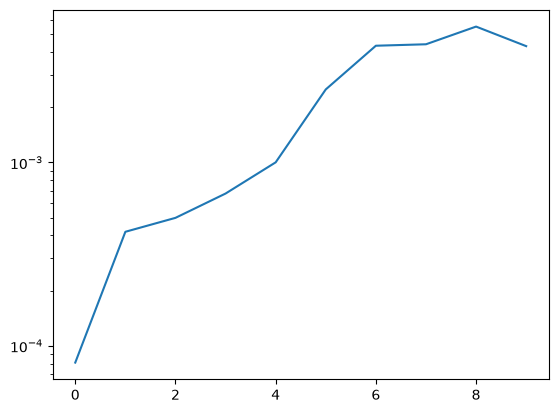

In [67]:
plt.semilogy(np.arange(POD_dim),((a_pred - a_true)**2).mean(dim=0).detach())
plt.show()


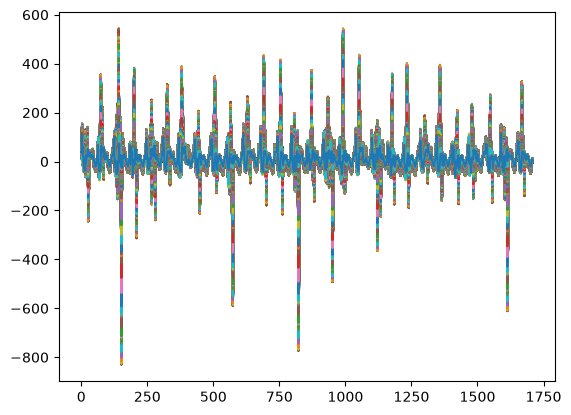

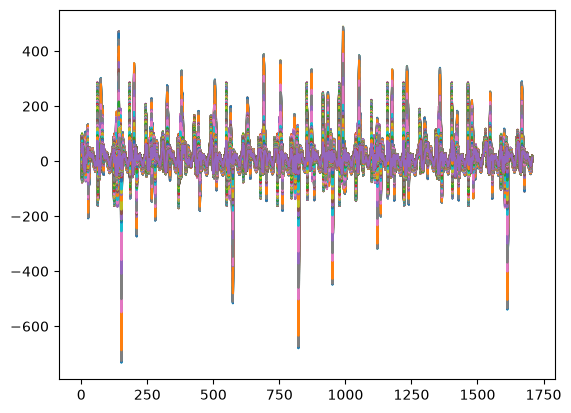

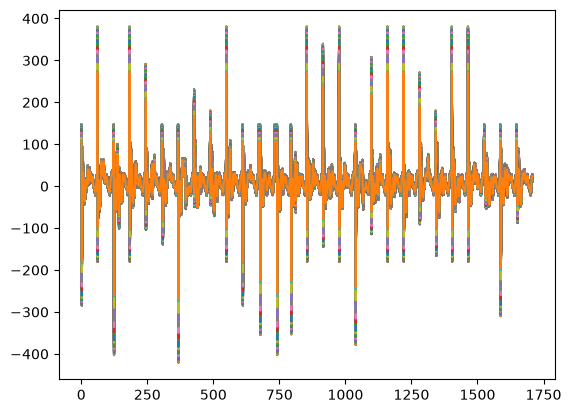

In [17]:
loss = nn.MSELoss()
set = train_dataset
pred = shred.post(shred(set.X))
truth = shred.post(set.Y)
plt.plot((pred - truth).detach() @ c1_picker.T)
plt.show()
plt.plot((pred - truth).detach() @ c2_picker.T)
plt.show()
plt.plot((pred - truth).detach() @ sus_picker.T)
plt.show()

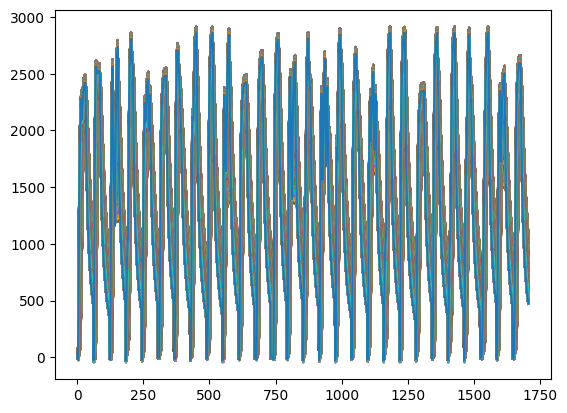

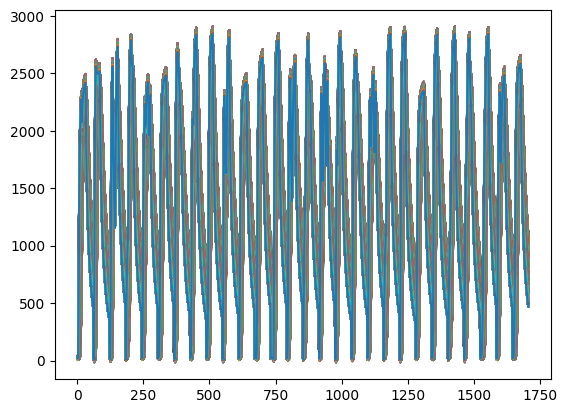

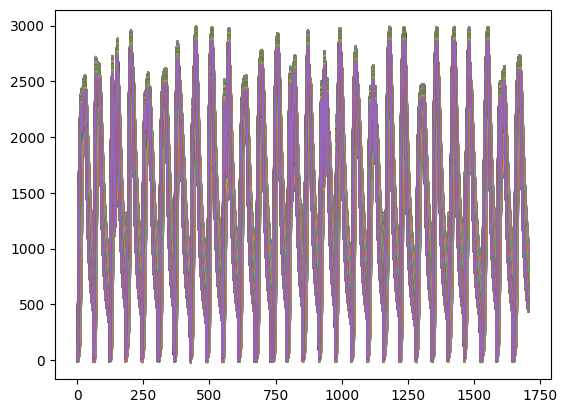

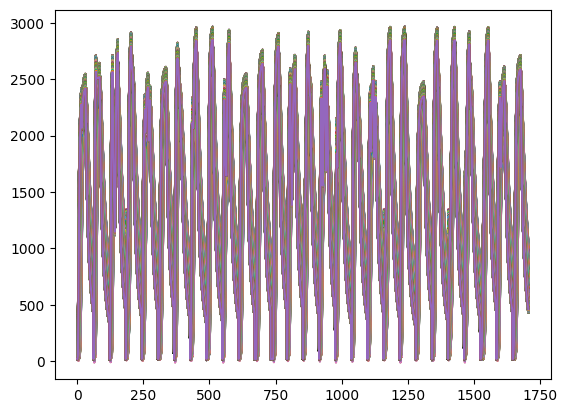

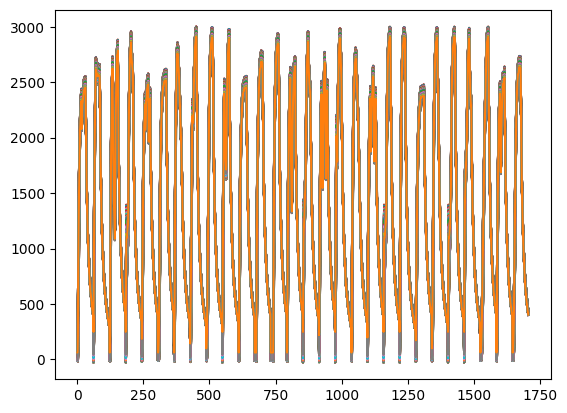

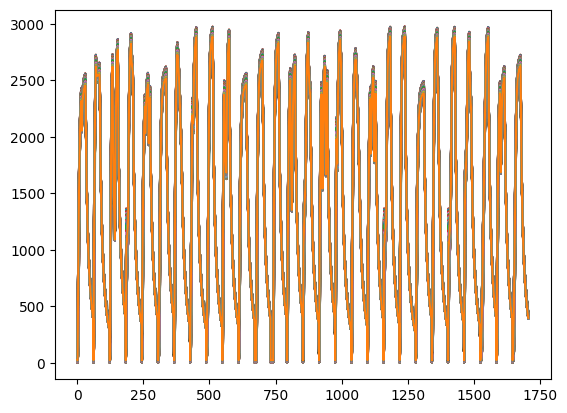

In [120]:
pred = shred.post(shred(set.X)).detach()
truth = shred.post(set.Y).detach()
plt.plot(pred @ c1_picker.T)
plt.show()
plt.plot(truth @ c1_picker.T)
plt.show()
plt.plot(pred @ c2_picker.T)
plt.show()
plt.plot(truth @ c2_picker.T)
plt.show()
plt.plot(pred @ sus_picker.T)
plt.show()
plt.plot(truth @ sus_picker.T)
plt.show()

In [81]:
train_dataset_forecaster, valid_dataset_forecaster, test_dataset_forecaster = manager.make_FORECASTER_datasets(shred)


In [82]:
remove_idx = 1 #Removing cooling
mask = torch.ones(train_dataset_forecaster.X.shape[-1],dtype=torch.bool)
mask[remove_idx] = False
train_dataset_forecaster.X = train_dataset_forecaster.X[:,:,mask]
valid_dataset_forecaster.X = valid_dataset_forecaster.X[:,:,mask]
test_dataset_forecaster.X = test_dataset_forecaster.X[:,:,mask]


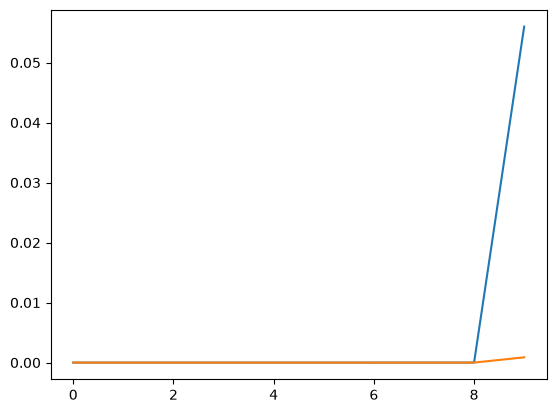

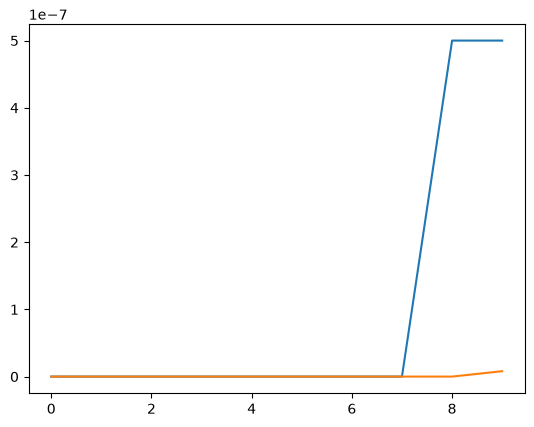

In [38]:
i = 62
plt.plot(test_dataset_forecaster.X[i,:,:2].detach())
plt.show()
plt.plot(test_dataset.X[i,:,:].detach())
plt.show()
# plt.plot(test_dataset_forecaster.Y[:61,10].detach())

In [83]:
forecaster = SHREDForecaster(
    u_dim=train_dataset_forecaster.X.shape[-1], 
    out_dim=train_dataset_forecaster.Y.shape[-1], 
    lstm_params = {
                'seq_len': 10, 
                'n_layers': 1,
                'hidden_dim': 64,
                },
    batch_first=True,
    data_manager=None,
)

-----Epoch 0-----
Training loss  : 0.008007266110955523
Validation loss: 0.0036112486850470304
-----Epoch 1-----
Training loss  : 0.0027138154837302864
Validation loss: 0.0013558986829593778
-----Epoch 2-----
Training loss  : 0.0013347127018138194
Validation loss: 0.0007755536353215575
-----Epoch 3-----
Training loss  : 0.0008895728052056467
Validation loss: 0.0005158634739927948
-----Epoch 4-----
Training loss  : 0.000657776520641234
Validation loss: 0.00038491579471156
-----Epoch 5-----
Training loss  : 0.0005139393772249325
Validation loss: 0.0002948768378701061
-----Epoch 6-----
Training loss  : 0.00041762675839261367
Validation loss: 0.0002441069664200768
-----Epoch 7-----
Training loss  : 0.00035085605542497855
Validation loss: 0.00020497989316936582
-----Epoch 8-----
Training loss  : 0.00029766013456257776
Validation loss: 0.0001766376371961087
-----Epoch 9-----
Training loss  : 0.00026288616041151376
Validation loss: 0.0001532501628389582
-----Epoch 10-----
Training loss  : 0.0

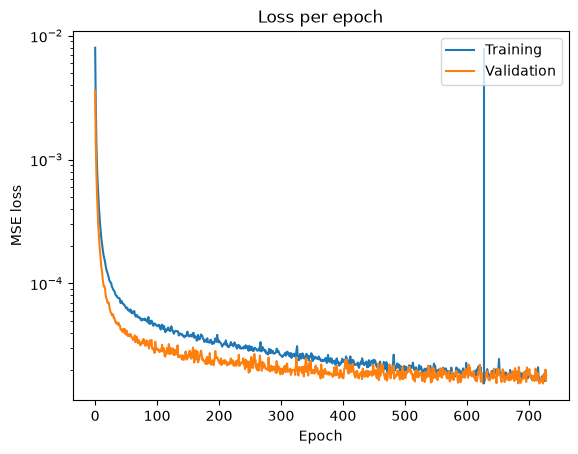

SHREDForecaster(
  (lstm): LSTM(
    (lstm): LSTM(66, 64, batch_first=True)
  )
  (proj): Linear(in_features=64, out_features=64, bias=True)
)

In [84]:
learning_rate = 1e-3
weight_decay  = 0.1
optimizer = optim.AdamW(forecaster.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss = nn.MSELoss()
# loss = nn.MSELoss()
train_error, valid_error = forecaster.fit(
    train_dataset_forecaster, 
    valid_dataset_forecaster, 
    optimizer, 
    loss, 
    batch_size = 64, 
    max_epoch = 10000, 
    patience = 100, 
    plotting = True
    )
forecaster.eval()

In [85]:
torch.save(forecaster.state_dict(), 'forecaster_weights_4.json')

In [86]:
forecaster_weights = torch.load('forecaster_weights_4.json')
forecaster.load_state_dict(forecaster_weights)
forecaster.eval()

SHREDForecaster(
  (lstm): LSTM(
    (lstm): LSTM(66, 64, batch_first=True)
  )
  (proj): Linear(in_features=64, out_features=64, bias=True)
)

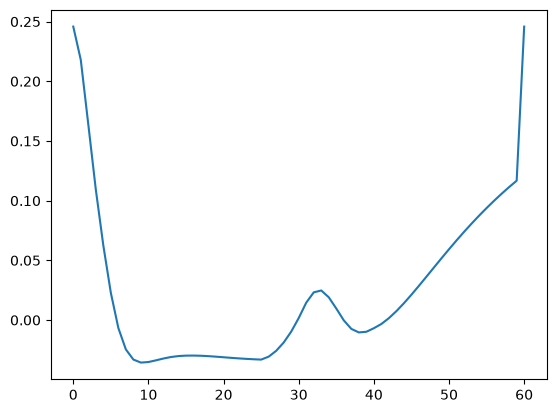

In [74]:
# plt.plot(test_dataset_forecaster.X[:61,-1,:3].detach())
plt.plot(test_dataset_forecaster.Y[:61,1].detach())

tensor(749366.)


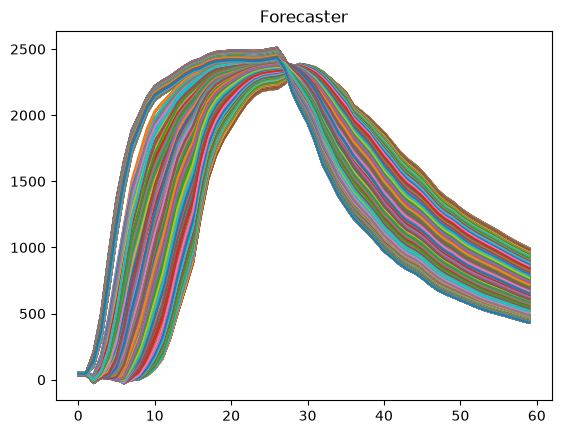

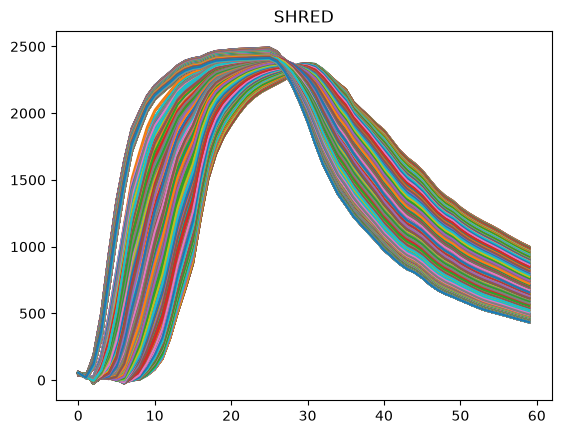

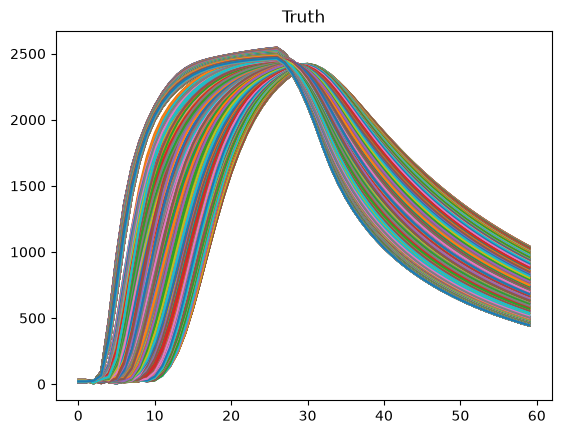

In [88]:
set = test_dataset_forecaster
pred = shred.post(shred.sdn(forecaster(set.X[:60]))).detach()
truth = shred.post(shred.sdn(set.Y[:60])).detach()
truth2 = shred.post(test_dataset.Y[:60]).detach()
print(((pred - truth)**2).sum(dim=1).mean())
plt.plot(pred @ c1_picker.T)
plt.title('Forecaster')
plt.show()
plt.plot(truth @ c1_picker.T)
plt.title('SHRED')
plt.show()
plt.plot(truth2 @ c1_picker.T)
plt.title('Truth')
plt.show()
# plt.plot(pred @ c2_picker.T)
# plt.show()
# # plt.plot(truth @ c2_picker.T)
# # plt.show()
# plt.plot(pred @ sus_picker.T)
# plt.show()
# plt.plot(truth @ sus_picker.T)
# plt.show()
